In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Cargar el dataset subiendo un nivel hacia /data
df = pd.read_csv("../data/dataset.csv")

print(f"Dataset cargado exitosamente. Total de observaciones: {len(df)}")
df.head()

Dataset cargado exitosamente. Total de observaciones: 638


,gameId,Multiplicador
0,17385155815,2.19
1,17385155915,1.55
2,17385156015,2.27
3,17385156115,6.42
4,17385156215,1.70


In [12]:
def audit_fixed_target_strategy(
    df: pd.DataFrame,
    target_multiplier: float = 2.0,
    bet_amount: float = 500.0,
    multiplier_col: str = "Multiplicador",
) -> dict:
    """Simula una estrategia de cobro automático (auto-cashout) a un multiplicador objetivo.

    Calcula la ganancia/pérdida neta, la tasa de éxito, el bankroll mínimo
    requerido (Drawdown máximo) y la racha de pérdidas más larga.
    """
    multipliers = df[multiplier_col].values
    total_rounds = len(multipliers)

    if total_rounds == 0:
        raise ValueError("El DataFrame no contiene observaciones.")

    # 1. Determinar victorias
    wins = multipliers >= target_multiplier
    win_count = np.sum(wins)
    win_rate = win_count / total_rounds

    # 2. PnL por ronda
    pnl_per_round = np.where(
        wins, bet_amount * (target_multiplier - 1.0), -bet_amount
    )
    cumulative_pnl = np.cumsum(pnl_per_round)

    # 3. Resultado final y presupuesto mínimo
    net_profit_loss = cumulative_pnl[-1]
    min_balance_reached = np.min(cumulative_pnl)
    min_required_bankroll = (
        abs(min_balance_reached) if min_balance_reached < 0 else bet_amount
    )

    # 4. Racha de pérdidas consecutivas más larga
    loss_streaks = []
    current_streak = 0
    for win in wins:
        if not win:
            current_streak += 1
        else:
            if current_streak > 0:
                loss_streaks.append(current_streak)
                current_streak = 0
    if current_streak > 0:
        loss_streaks.append(current_streak)

    max_loss_streak = max(loss_streaks) if loss_streaks else 0

    estado_resultado = (
        "GANANCIA"
        if net_profit_loss > 0
        else ("PÉRDIDA" if net_profit_loss < 0 else "SIN CAMBIO")
    )

    return {
        "Target": f"{target_multiplier:.2f}x",
        "Apuesta (COP)": bet_amount,
        "Total Rondas": total_rounds,
        "Victorias": int(win_count),
        "Derrotas": int(total_rounds - win_count),
        "Win Rate (%)": round(win_rate * 100, 2),
        "Resultado": estado_resultado,
        "Ganancia / Pérdida Neta (COP)": round(net_profit_loss, 2),
        "Presupuesto Mínimo (COP)": round(min_required_bankroll, 2),
        "Racha Max Derrotas": max_loss_streak,
        "ROI (%)": round(
            (net_profit_loss / (total_rounds * bet_amount)) * 100, 2
        ),
    }


def compare_target_multipliers(
    df: pd.DataFrame,
    targets: list = [1.1, 1.2, 1.35, 1.5, 1.75, 2.0, 3.0, 5.0],
    bet_amount: float = 500.0,
    multiplier_col: str = "Multiplicador",
) -> pd.DataFrame:
    """Ejecuta la auditoría para múltiples targets y consolida los resultados en un DataFrame."""
    results = [
        audit_fixed_target_strategy(
            df=df,
            target_multiplier=target,
            bet_amount=bet_amount,
            multiplier_col=multiplier_col,
        )
        for target in targets
    ]
    return pd.DataFrame(results)

In [13]:
targets_to_test = [1.1, 1.2, 1.35, 1.5, 1.75, 2.0, 3.0, 5.0]

df_results = compare_target_multipliers(
    df=df,
    targets=targets_to_test,
    bet_amount=500.0,
    multiplier_col="Multiplicador",
)

display(df_results)

,Target,Apuesta (COP),Total Rondas,Victorias,Derrotas,Win Rate (%),Resultado,Ganancia / Pérdida Neta (COP),Presupuesto Mínimo (COP),Racha Max Derrotas,ROI (%)
0,1.10x,500.0,638,563,75,88.24,PÉRDIDA,-9350.0,10500.0,3,-2.93
1,1.20x,500.0,638,508,130,79.62,PÉRDIDA,-14200.0,14700.0,3,-4.45
2,1.35x,500.0,638,454,184,71.16,PÉRDIDA,-12550.0,13400.0,4,-3.93
3,1.50x,500.0,638,415,223,65.05,PÉRDIDA,-7750.0,8000.0,4,-2.43
4,1.75x,500.0,638,358,280,56.11,PÉRDIDA,-5750.0,8250.0,7,-1.80
5,2.00x,500.0,638,315,323,49.37,PÉRDIDA,-4000.0,9000.0,10,-1.25
6,3.00x,500.0,638,208,430,32.60,PÉRDIDA,-7000.0,12000.0,13,-2.19
7,5.00x,500.0,638,123,515,19.28,PÉRDIDA,-11500.0,15000.0,20,-3.61


¿Cómo interpretar las métricas obtenidas?
1. Presupuesto Mínimo (COP): Mide la peor racha acumulada (Drawdown). Aunque una estrategia al final de 638 rondas resulte en ganancia, si en el transcurso la curva de capital cayó hasta $-\$20,000$, ese valor representa la banca mínima indispensable que debiste tener desde el día 1 para no quebrarte antes de recuperar el capital.

2. Racha Max Derrotas: Cuántas rondas seguidas ocurrieron sin alcanzar el target. Ayuda a evaluar el impacto psicológico o la probabilidad de ruina extrema.

3. ROI (%): Mide la eficiencia del capital apostado total frente al beneficio o pérdida neta real al cabo de la serie de $n = 638$ observaciones.

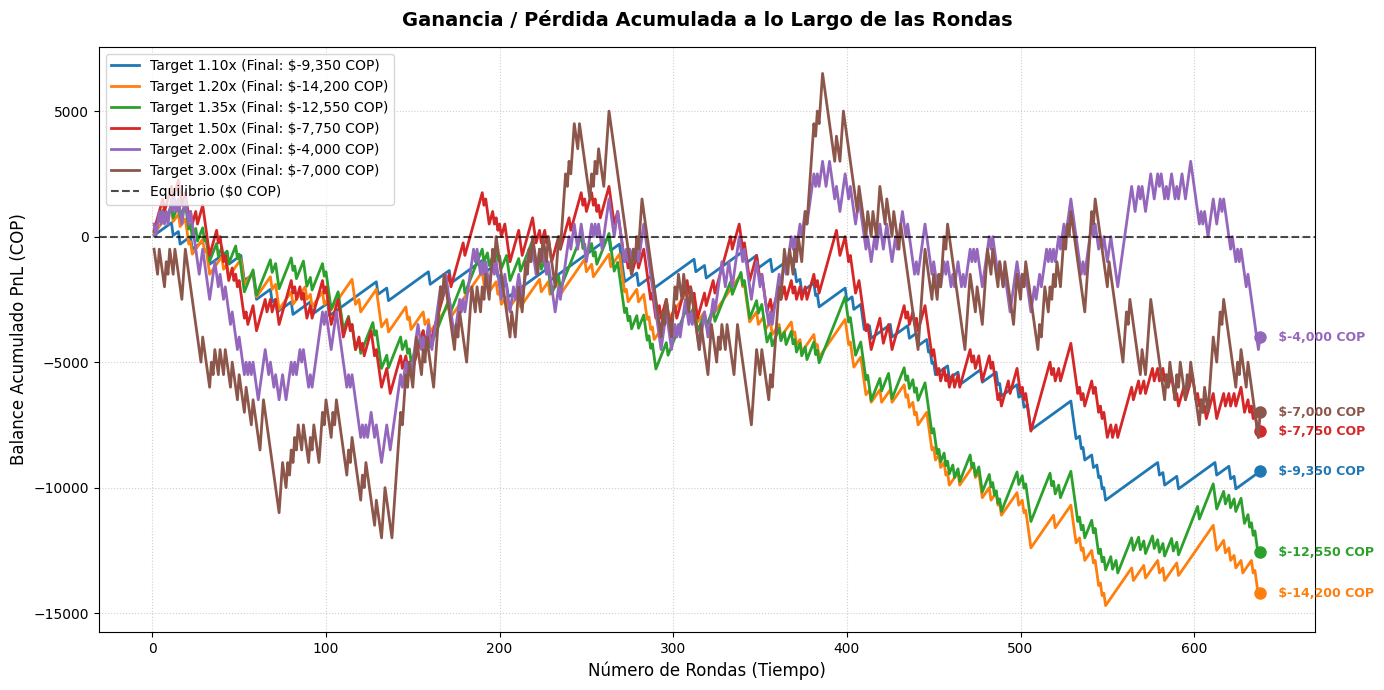

In [14]:
def plot_equity_curves(
    df: pd.DataFrame,
    targets: list = [1.1, 1.2, 1.35, 1.5, 2.0, 3.0],
    bet_amount: float = 500.0,
    multiplier_col: str = "Multiplicador",
):
    plt.figure(figsize=(14, 7))

    multipliers = df[multiplier_col].values
    total_rounds = len(multipliers)
    rounds = np.arange(1, total_rounds + 1)

    for target in targets:
        wins = multipliers >= target
        pnl_per_round = np.where(
            wins, bet_amount * (target - 1.0), -bet_amount
        )
        cumulative_pnl = np.cumsum(pnl_per_round)

        final_pnl = cumulative_pnl[-1]
        signo = "+" if final_pnl >= 0 else ""

        line = plt.plot(
            rounds,
            cumulative_pnl,
            label=f"Target {target:.2f}x (Final: {signo}${final_pnl:,.0f} COP)",
            linewidth=2,
        )

        last_color = line[0].get_color()
        plt.plot(
            total_rounds, final_pnl, marker="o", markersize=8, color=last_color
        )
        plt.annotate(
            f" {signo}${final_pnl:,.0f} COP",
            (total_rounds, final_pnl),
            textcoords="offset points",
            xytext=(10, -3),
            ha="left",
            fontsize=9,
            fontweight="bold",
            color=last_color,
        )

    plt.axhline(
        0, color="black", linestyle="--", alpha=0.7, label="Equilibrio ($0 COP)"
    )

    plt.title(
        "Ganancia / Pérdida Acumulada a lo Largo de las Rondas",
        fontsize=14,
        pad=15,
        fontweight="bold",
    )
    plt.xlabel("Número de Rondas (Tiempo)", fontsize=12)
    plt.ylabel("Balance Acumulado PnL (COP)", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", fontsize=10)
    plt.tight_layout()

    plt.show()


plot_equity_curves(
    df=df,
    targets=[1.1, 1.2, 1.35, 1.5, 2.0, 3.0],
    bet_amount=500.0,
    multiplier_col="Multiplicador",
)

¿Cómo interpretar este gráfico en tu análisis?

1. La pendiente de la curva: Una línea que sube de forma constante indica una estrategia consistente, mientras que una línea con caída libre sostenida muestra una estrategia con expectativa matemática negativa.

2. Los valles (Drawdown): Cada vez que la línea cae por debajo de cero (o de su punto más alto previo), esa profundidad en el eje $Y$ representa el presupuesto o pozo mínimo indispensable que debiste tener en ese momento exacto para soportar la racha sin quedar en ceros.

3. Cruce de líneas: Verás cómo targets más bajos (ej. 1.2x) suelen generar curvas mucho más "suaves" y menos volátiles (menor Drawdown), mientras que targets más altos (ej. 3.0x) presentan caídas pronunciadas y peldaños empinados cuando aciertan.